In [1]:
import sys

sys.path.append(r"C:\Users\nigel\Desktop\prax\robust-anomaly-cifar10")
print("Project path added!")


Project path added!


In [5]:
import torch
import matplotlib.pyplot as plt
from torchvision import transforms
from torch.utils.data import DataLoader

from src.dataset import CorruptedCIFAR10


In [12]:
transform = transforms.Compose([
    transforms.ToTensor()
])

dataset = CorruptedCIFAR10(
    root=r"C:\Users\nigel\Desktop\prax\robust-anomaly-cifar10\data\raw",
    train=True,
    download=True,
    transform=transform,
    corruption_type="cutout",  # try: gaussian_blur, brightness, cutout
    severity=3,
    corruption_prob=1.0
)

loader = DataLoader(dataset, batch_size=16, shuffle=True)
clean, corrupted, labels = next(iter(loader))

print("Batch loaded:", clean.shape, corrupted.shape)


Batch loaded: torch.Size([16, 3, 32, 32]) torch.Size([16, 3, 32, 32])


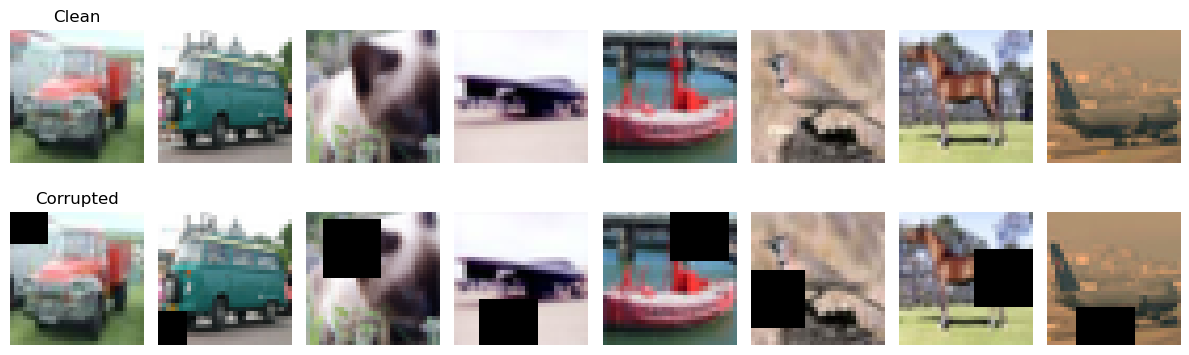

In [13]:
def show_batch(clean, corrupted, n=8):
    plt.figure(figsize=(12, 4))

    for i in range(n):
        # clean
        plt.subplot(2, n, i + 1)
        plt.imshow(clean[i].permute(1, 2, 0))
        plt.axis("off")
        if i == 0:
            plt.title("Clean")

        # corrupted
        plt.subplot(2, n, n + i + 1)
        plt.imshow(corrupted[i].permute(1, 2, 0))
        plt.axis("off")
        if i == 0:
            plt.title("Corrupted")

    plt.tight_layout()
    plt.show()

show_batch(clean, corrupted, n=8)
